#### Import Libraries and General Settings

In [160]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
import matplotlib

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

Python: 3.11.14 (main, Oct 10 2025, 08:54:03) [GCC 11.4.0]
numpy: 2.4.1
pandas: 3.0.0
matplotlib: 3.10.8
seaborn: 0.13.2


#### Load dataset

In [161]:
melbourne_file_path = "dataset/melb_data.csv"
melbourne_data = pd.read_csv(melbourne_file_path)

#### Display dataset

In [162]:
melbourne_data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


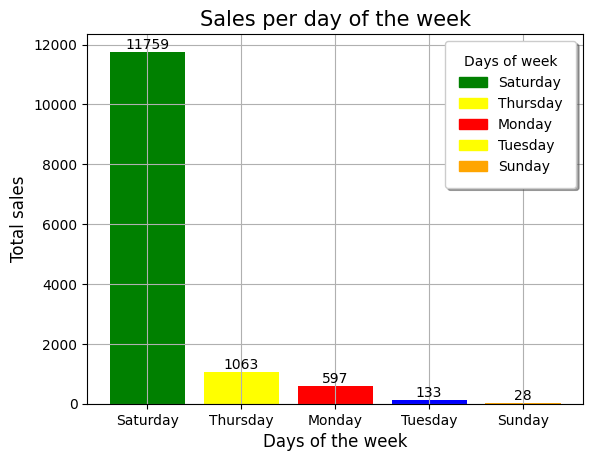

,Saturday,Thursday,Monday,Tuesday,Sunday
0,11759,1063,597,133,28


In [163]:
melbourne_data["Date"] = pd.to_datetime(
    melbourne_data["Date"], dayfirst=True, errors="raise"
)
weekday = melbourne_data["Date"].dt.strftime("%A")
weekday_df = pd.DataFrame(weekday)
columns = weekday_df["Date"].unique().tolist()
values = weekday_df.value_counts().to_list()
week_days_df = pd.DataFrame([values], columns=columns)
x = weekday_df["Date"].unique().tolist()
y = weekday_df.value_counts().to_list()
bar_colors = ["green", "yellow", "red", "blue", "orange"]
plt.title("Sales per day of the week", fontsize=15)
plt.xlabel("Days of the week", fontsize=12)
plt.ylabel("Total sales", fontsize=12)
plt.bar_label(plt.bar(x, y, label=x))
plt.bar(x, y, color=bar_colors)
SA = mpatches.Patch(color="green", label="Saturday")
TH = mpatches.Patch(color="yellow", label="Thursday")
MO = mpatches.Patch(color="red", label="Monday")
TU = mpatches.Patch(color="yellow", label="Tuesday")
SU = mpatches.Patch(color="orange", label="Sunday")
plt.legend(
    handles=[SA, TH, MO, TU, SU],
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    title="Days of week",
)
plt.grid()
plt.show()

display(week_days_df)

#### Function to add labels to charts

In [164]:
def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha="center", bbox=dict(facecolor="white", alpha=0.8))

#### Create a dataset with one column for the number of rooms and one for the price

In [165]:
price = melbourne_data["Price"]
df_price = price.to_frame()
rooms = melbourne_data.Rooms
df_rooms = pd.get_dummies(rooms, prefix="Room", columns=["Rooms"], dtype=int)
df_rooms_price = pd.concat(
    [df_rooms.reset_index(drop=True), df_price.reset_index(drop=True)], axis=1
)
df_rooms_price.sample(5)

,Room_1,Room_2,Room_3,Room_4,Room_5,Room_6,Room_7,Room_8,Room_10,Price
1451,1,0,0,0,0,0,0,0,0,351000.0
4873,0,1,0,0,0,0,0,0,0,1500000.0
1930,0,1,0,0,0,0,0,0,0,953000.0
1823,0,1,0,0,0,0,0,0,0,536000.0
4720,1,0,0,0,0,0,0,0,0,500000.0


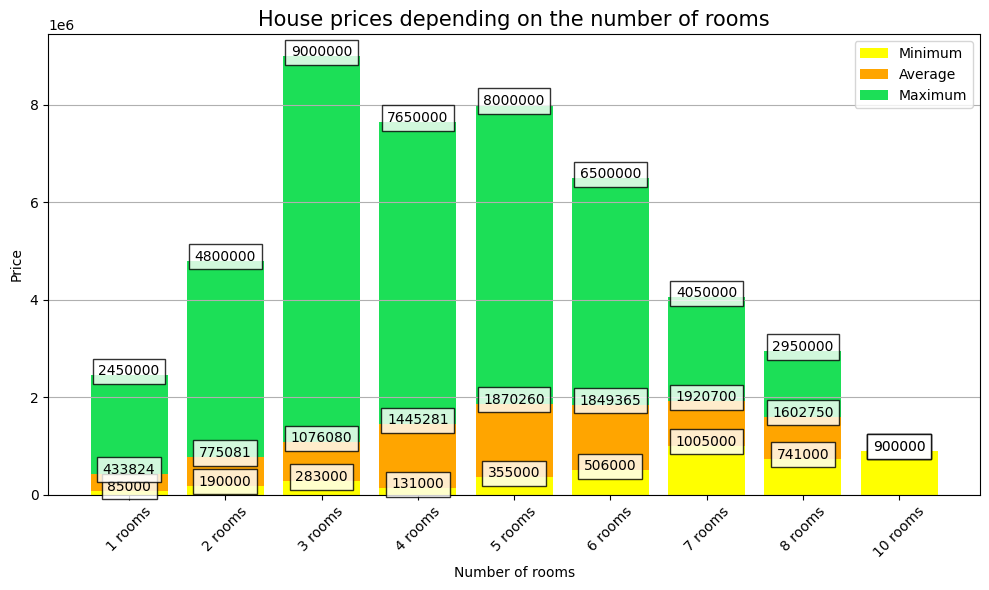

,Average,Minimum,Maximum,count
room,,,,
Room_1,433824,85000,2450000,681
Room_2,775081,190000,4800000,3648
Room_3,1076080,283000,9000000,5881
Room_4,1445281,131000,7650000,2688
Room_5,1870260,355000,8000000,596
Room_6,1849365,506000,6500000,67
Room_7,1920700,1005000,4050000,10
Room_8,1602750,741000,2950000,8
Room_10,900000,900000,900000,1


In [166]:
room_order = [
    "Room_1",
    "Room_2",
    "Room_3",
    "Room_4",
    "Room_5",
    "Room_6",
    "Room_7",
    "Room_8",
    "Room_10",
]

stats = (
    df_rooms_price.melt(
        id_vars="Price", value_vars=room_order, var_name="room", value_name="flag"
    )
    .query("flag == 1")
    .groupby("room")["Price"]
    .agg(mean="mean", min="min", max="max", count="size")
    .astype(int)
    .reindex(room_order)
)
room_df = stats.rename(columns={"mean": "Average", "min": "Minimum", "max": "Maximum"})

min_prices = stats["min"].values
mean_prices = stats["mean"].values
max_prices = stats["max"].values

x = range(len(min_prices))
labels = [f"{r.split('_')[1].split('.')[0]} rooms" for r in stats.index]

plt.figure(figsize=(10, 6))

plt.bar(x, min_prices, color="yellow", label="Minimum")
add_labels(x, min_prices)

plt.bar(x, mean_prices - min_prices, bottom=min_prices, color="orange", label="Average")
add_labels(x, mean_prices)

plt.bar(
    x, max_prices - mean_prices, bottom=mean_prices, color="#1cdf57", label="Maximum"
)
add_labels(x, max_prices)

plt.xticks(x, labels, rotation=45)
plt.title("House prices depending on the number of rooms", fontsize=15)
plt.xlabel("Number of rooms")
plt.ylabel("Price")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

display(room_df)

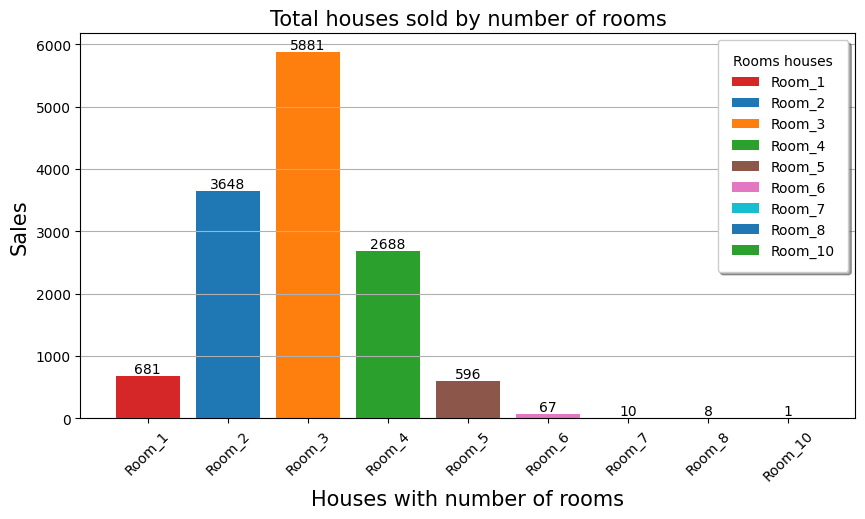

,Room_1,Room_2,Room_3,Room_4,Room_5,Room_6,Room_7,Room_8,Room_10
0,681,3648,5881,2688,596,67,10,8,1


In [167]:
room_cols = [
    "Room_1",
    "Room_2",
    "Room_3",
    "Room_4",
    "Room_5",
    "Room_6",
    "Room_7",
    "Room_8",
    "Room_10",
]

results = [df_rooms_price[["Price"]].loc[df_rooms_price[col] == 1] for col in room_cols]

total_houses_sold_by_number_of_rooms = [len(r) for r in results]
total_houses_sold_by_number_of_rooms_df = pd.DataFrame(
    total_houses_sold_by_number_of_rooms
)
total_houses_sold_by_number_of_rooms_df.T
total_houses_sold_by_number_of_rooms_df = (
    total_houses_sold_by_number_of_rooms_df.set_index(df_rooms.columns)
)

fig, ax = plt.subplots(figsize=(10, 5))
df_bedrooms2 = melbourne_data[["Bedroom2"]]
rooms = df_rooms.columns
total_houses = total_houses_sold_by_number_of_rooms
bar_labels = df_rooms.columns
bar_colors = [
    "tab:red",
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:brown",
    "tab:pink",
    "tab:cyan",
    "tab:blue",
    "tab:green",
    "tab:red",
    "tab:blue",
    "tab:purple",
]
plt.bar_label(plt.bar(rooms, total_houses, label=rooms, color=bar_colors))
plt.xticks(rotation=45)
ax.set_ylabel("Sales", fontsize=15)
ax.set_xlabel("Houses with number of rooms", fontsize=15)
ax.set_title("Total houses sold by number of rooms", fontsize=15)
ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    title="Rooms houses",
)
plt.grid(axis="y")
plt.show()

display(total_houses_sold_by_number_of_rooms_df.T)

#### Create a dataset with one column for the number of bedrooms and one for the price

In [168]:
rooms2 = melbourne_data.Bedroom2.astype(int)
df_rooms2 = pd.get_dummies(rooms2, prefix="Bedrooms", columns=["Bedroom2"], dtype=int)
df_rooms2_price = pd.concat(
    [df_rooms2.reset_index(drop=True), df_price.reset_index(drop=True)], axis=1
)
df_rooms2_price.sample(5)

,Bedrooms_0,Bedrooms_1,Bedrooms_2,Bedrooms_3,Bedrooms_4,Bedrooms_5,Bedrooms_6,Bedrooms_7,Bedrooms_8,Bedrooms_9,Bedrooms_10,Bedrooms_20,Price
2815,0,1,0,0,0,0,0,0,0,0,0,0,328000.0
3035,0,0,0,0,1,0,0,0,0,0,0,0,1250000.0
4777,0,0,0,1,0,0,0,0,0,0,0,0,1100000.0
3956,0,0,0,0,1,0,0,0,0,0,0,0,1180000.0
11952,0,1,0,0,0,0,0,0,0,0,0,0,430000.0


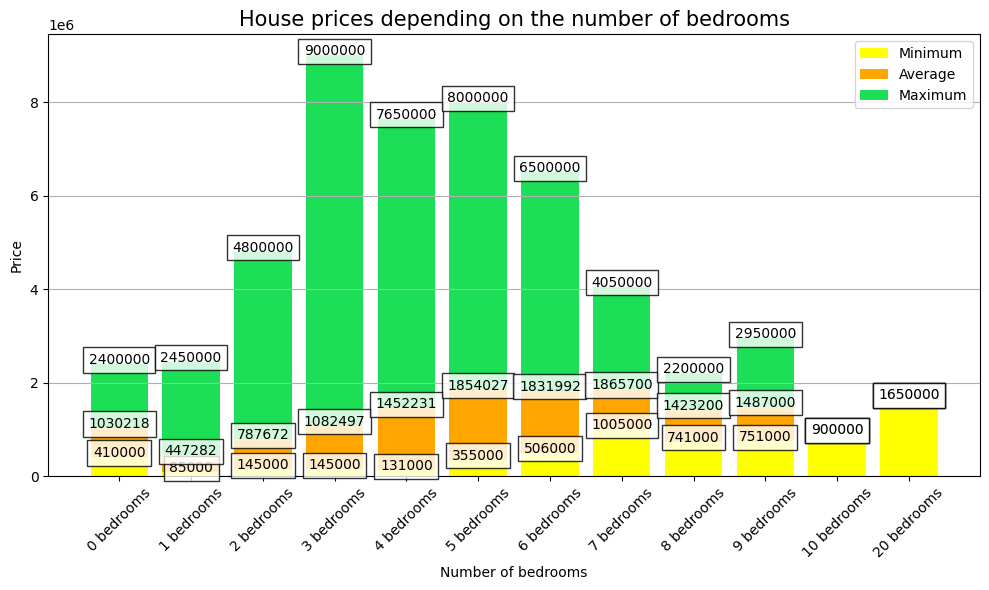

,Average,Minimum,Maximum,count
room,,,,
Bedrooms_0,1030218,410000,2400000,16
Bedrooms_1,447282,85000,2450000,691
Bedrooms_2,787672,145000,4800000,3737
Bedrooms_3,1082497,145000,9000000,5896
Bedrooms_4,1452231,131000,7650000,2601
Bedrooms_5,1854027,355000,8000000,556
Bedrooms_6,1831992,506000,6500000,63
Bedrooms_7,1865700,1005000,4050000,10
Bedrooms_8,1423200,741000,2200000,5


In [169]:
room_order = [
    "Bedrooms_0", "Bedrooms_1", "Bedrooms_2", "Bedrooms_3",
    "Bedrooms_4", "Bedrooms_5", "Bedrooms_6", "Bedrooms_7",
    "Bedrooms_8", "Bedrooms_9", "Bedrooms_10", "Bedrooms_20"
]

stats = (
    df_rooms2_price
        .melt(id_vars="Price", value_vars=room_order,
              var_name="room", value_name="flag")
        .query("flag == 1")
        .groupby("room")["Price"]
        .agg(mean="mean", min="min", max="max", count="size")
        .astype(int)
        .reindex(room_order)
)
room2_df = stats.rename(
    columns={"mean": "Average", "min": "Minimum", "max": "Maximum"}
)

min_prices = stats["min"].values
mean_prices = stats["mean"].values
max_prices = stats["max"].values

x = range(len(min_prices)) 
labels = [f"{r.split('_')[1].split('.')[0]} bedrooms" for r in stats.index]

plt.figure(figsize=(10, 6))

plt.bar(x, min_prices, color="yellow", label="Minimum")
add_labels(x, min_prices) 

plt.bar(x, mean_prices - min_prices, bottom=min_prices, color="orange", label="Average")
add_labels(x, mean_prices) 

plt.bar(x, max_prices - mean_prices, bottom=mean_prices, color="#1cdf57", label="Maximum")
add_labels(x, max_prices) 

plt.xticks(x, labels, rotation=45)
plt.title("House prices depending on the number of bedrooms", fontsize=15)
plt.xlabel("Number of bedrooms")
plt.ylabel("Price")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

display(room2_df)

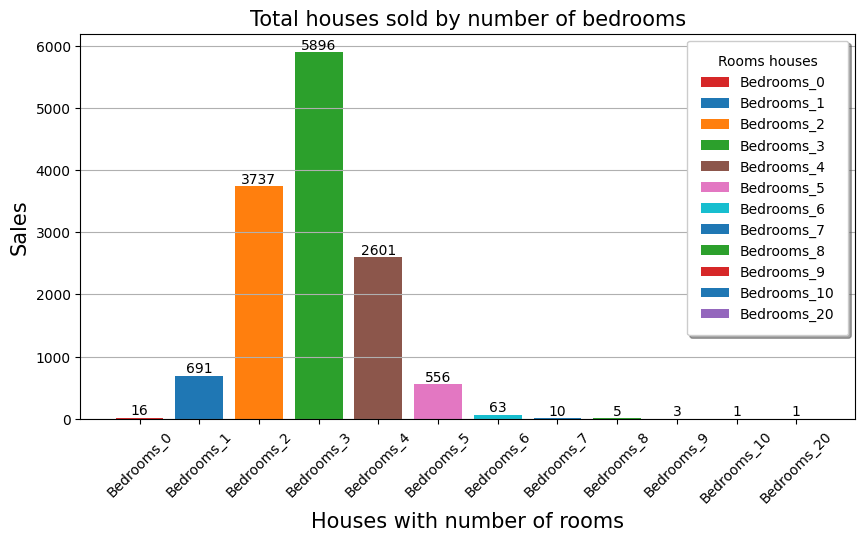

,Bedrooms_0,Bedrooms_1,Bedrooms_2,Bedrooms_3,Bedrooms_4,Bedrooms_5,Bedrooms_6,Bedrooms_7,Bedrooms_8,Bedrooms_9,Bedrooms_10,Bedrooms_20
0,16,691,3737,5896,2601,556,63,10,5,3,1,1


In [170]:
room_cols = [
    "Bedrooms_0",
    "Bedrooms_1",
    "Bedrooms_2",
    "Bedrooms_3",
    "Bedrooms_4",
    "Bedrooms_5",
    "Bedrooms_6",
    "Bedrooms_7",
    "Bedrooms_8",
    "Bedrooms_9",
    "Bedrooms_10",
    "Bedrooms_20",
]

results = [
    df_rooms2_price[["Price"]].loc[df_rooms2_price[col] == 1] for col in room_cols
]

total_houses_sold_by_number_of_rooms = [len(r) for r in results]
total_houses_sold_by_number_of_rooms_df = pd.DataFrame(
    total_houses_sold_by_number_of_rooms
)
total_houses_sold_by_number_of_rooms_df.T
total_houses_sold_by_number_of_rooms_df = (
    total_houses_sold_by_number_of_rooms_df.set_index(df_rooms2.columns)
)

fig, ax = plt.subplots(figsize=(10, 5))
df_bedrooms2 = melbourne_data[["Bedroom2"]]
rooms = df_rooms2.columns
total_houses = total_houses_sold_by_number_of_rooms
bar_labels = df_rooms.columns
bar_colors = [
    "tab:red",
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:brown",
    "tab:pink",
    "tab:cyan",
    "tab:blue",
    "tab:green",
    "tab:red",
    "tab:blue",
    "tab:purple",
]
plt.bar_label(plt.bar(rooms, total_houses, label=rooms, color=bar_colors))
plt.xticks(rotation=45)
ax.set_ylabel("Sales", fontsize=15)
ax.set_xlabel("Houses with number of rooms", fontsize=15)
ax.set_title("Total houses sold by number of bedrooms", fontsize=15)
ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    title="Rooms houses",
)
plt.grid(axis="y")
plt.show()

display(total_houses_sold_by_number_of_rooms_df.T)

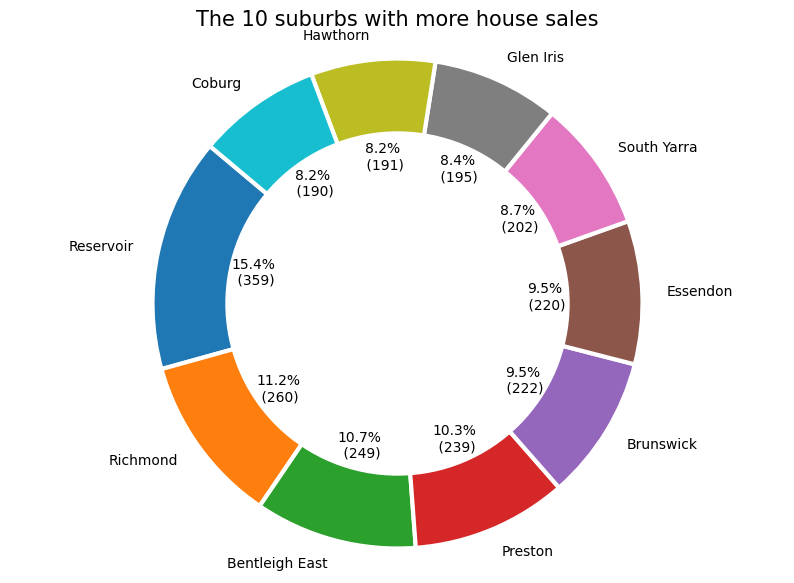

,Reservoir,Richmond,Bentleigh East,Preston,Brunswick,Essendon,South Yarra,Glen Iris,Hawthorn,Coburg
0,359,260,249,239,222,220,202,195,191,190


In [171]:
suburb = melbourne_data["Suburb"].value_counts()
first10_suburb = dict(itertools.islice(suburb.items(), 10))
top_10_suburbs_df = pd.DataFrame(first10_suburb, index=[0])
names = first10_suburb.keys()
size = first10_suburb.values()


def format_autopct(pct, sizes):
    absolute = int(round(pct / 100.0 * sum(sizes)))
    return f"{pct:.1f}%\n ({absolute})"


plt.figure(figsize=(10, 7))
my_circle = plt.Circle((0, 0), 0.7, color="white")
plt.title("The 10 suburbs with more house sales", fontsize=15)
plt.pie(
    size,
    labels=names,
    wedgeprops={"linewidth": 3, "edgecolor": "white"},
    autopct=lambda pct: format_autopct(pct, size),
    startangle=140,
)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.axis("equal")
plt.show()

display(top_10_suburbs_df)

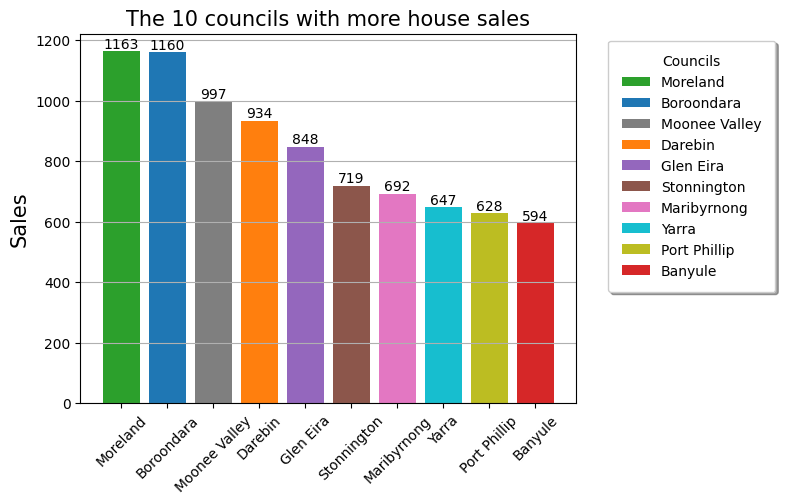

,Moreland,Boroondara,Moonee Valley,Darebin,Glen Eira,Stonnington,Maribyrnong,Yarra,Port Phillip,Banyule
0,1163,1160,997,934,848,719,692,647,628,594


In [172]:
council_area = melbourne_data['CouncilArea'].value_counts()
first10_council = dict(itertools.islice(council_area.items(),10))
top_10_councils_df = pd.DataFrame(first10_council, index=[0])
fig, ax = plt.subplots()
first10_keys = first10_council.keys()
first10_values = first10_council.values()
x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
bar_labels = first10_keys
bar_colors = [
    "tab:green",
    "tab:blue",
    "tab:grey",
    "tab:orange",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:cyan",
    "tab:olive",
    "tab:red",
]
ax.bar(bar_labels, first10_values)
plt.bar_label(plt.bar(first10_keys, first10_values, label=bar_labels, color=bar_colors))
ax.set_ylabel("Sales", fontsize=15)
ax.set_title("The 10 councils with more house sales", fontsize=15)
ax.legend(
    bbox_to_anchor=(1.05, 1),
    title="Councils",
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
)
ax.set_xticks(x, bar_labels, rotation=45)
plt.grid(axis="y")
plt.show()

display(top_10_councils_df)

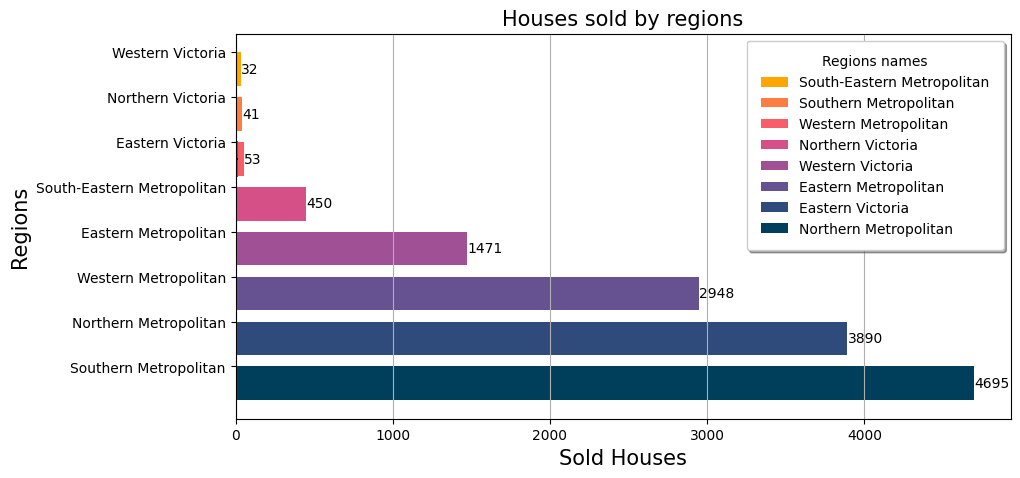

,Southern Metropolitan,Northern Metropolitan,Western Metropolitan,Eastern Metropolitan,South-Eastern Metropolitan,Eastern Victoria,Northern Victoria,Western Victoria
0,4695,3890,2948,1471,450,53,41,32


In [173]:
region_name = melbourne_data['Regionname'].value_counts()
region_names = {key: value for key, value in region_name.items()}
houses_sold_region_df = d=pd.DataFrame(region_names, index=[0])
region_names_keys = region_names.keys()
region_names_values = region_names.values()
inv_map = {k for k in region_names_keys}
y_pos = np.arange(len(region_names_keys))
performance = 3 + 10 * np.random.rand(len(region_names_keys))
error = np.random.rand(len(region_names_keys))
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.75
ind = np.arange(len(region_names_values))
bar_colors = (
    "#003f5c",
    "#2f4b7c",
    "#665191",
    "#a05195",
    "#d45087",
    "#f95d6a",
    "#ff7c43",
    "#ffa600",
)
legend_colors = bar_colors[::-1]
ax.barh(ind, region_names_values, width, color=bar_colors)
ax.set_yticks(ind + width / 2)
ax.set_yticklabels(region_names_keys, minor=False)
h = plt.barh(
    y_pos, performance, xerr=error, align="center", label=inv_map, color=legend_colors
)
ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    title="Regions names",
)

for i, v in enumerate(region_names_values):
    ax.text(v + 3, i, str(v), color="black", verticalalignment="center")
plt.title("Houses sold by regions", fontsize=15)
plt.xlabel("Sold Houses", fontsize=15)
plt.ylabel("Regions", fontsize=15)
plt.grid(axis="x")
plt.show()

display(houses_sold_region_df)

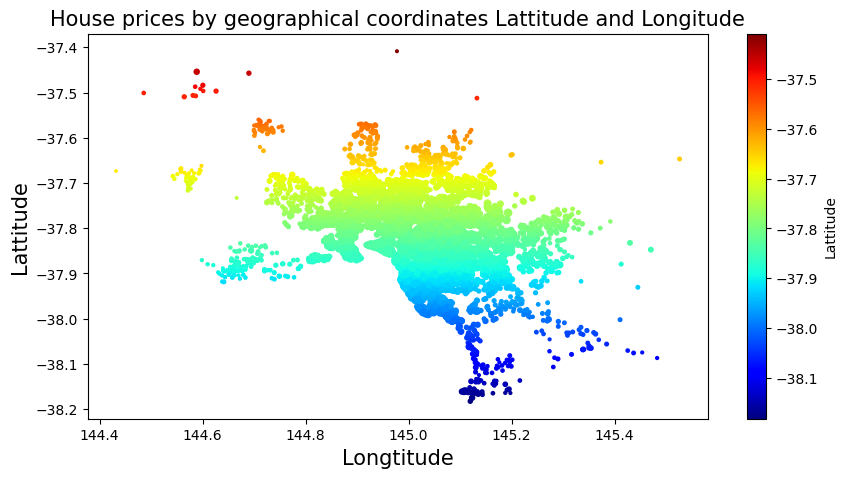

In [174]:
melbourne_data.plot(
    kind="scatter",
    x="Longtitude",
    y="Lattitude",
    alpha=1,
    s=melbourne_data["Price"] / 100000,
    figsize=(10, 5),
    c="Lattitude",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.title(
    "House prices by geographical coordinates Lattitude and Longitude", fontsize=15
)
plt.xlabel("Longtitude", fontsize=15)
plt.ylabel("Lattitude", fontsize=15)
plt.show()

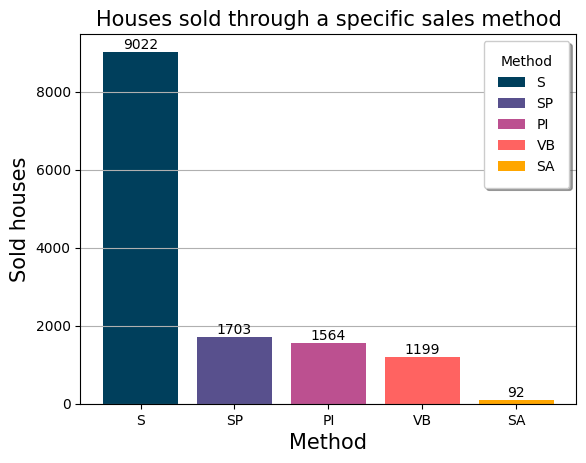

,S,SP,PI,VB,SA
0,9022,1703,1564,1199,92


In [175]:
method = melbourne_data['Method'].value_counts()
method_type = {key: value for key, value in method.items()}
method_type_df = pd.DataFrame(method_type, index=[0])
fig, ax = plt.subplots()
method_keys = method_type.keys()
method_values = method_type.values()
bar_labels = method_type.keys()
bar_colors = ["#003f5c", "#58508d", "#bc5090", "#ff6361", "#ffa600"]
ax.bar(method_keys, method_values, label=bar_labels, color=bar_colors)
ax.set_ylabel("Sold houses", fontsize=15)
ax.set_xlabel("Method", fontsize=15)
ax.set_title("Houses sold through a specific sales method", fontsize=15)
ax.legend(
    frameon=True, fancybox=True, framealpha=1, shadow=True, borderpad=1, title="Method"
)
plt.bar_label(
    plt.bar(
        method_type.keys(), method_type.values(), label=bar_labels, color=bar_colors
    )
)
plt.grid(axis="y")
plt.show()

display(method_type_df)

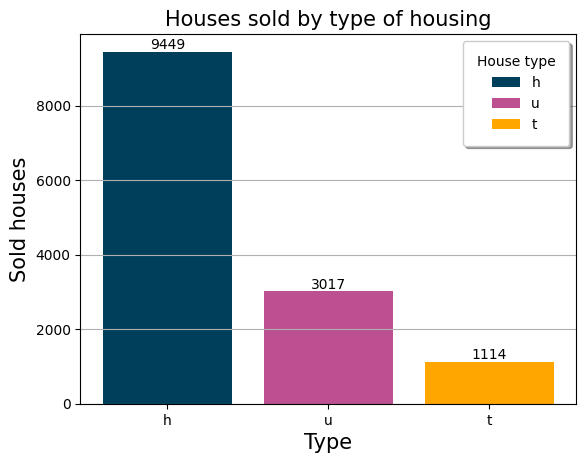

,h,u,t
0,9449,3017,1114


In [176]:
type = melbourne_data['Type'].value_counts()
house_type = {key: value for key, value in type.items()}
house_type_df = pd.DataFrame(house_type, index=[0])
fig, ax = plt.subplots()
type_keys = house_type.keys()
type_values = house_type.values()
bar_labels = house_type.keys()
bar_colors = ["#003f5c", "#bc5090", "#ffa600"]
ax.bar(type_keys, type_values, label=bar_labels, color=bar_colors)
ax.set_ylabel("Sold houses", fontsize=15)
ax.set_xlabel("Type", fontsize=15)
ax.set_title("Houses sold by type of housing", fontsize=15)
ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    title="House type",
)
plt.bar_label(
    plt.bar(house_type.keys(), house_type.values(), label=bar_labels, color=bar_colors)
)
plt.grid(axis="y")
plt.show()

display(house_type_df)

#### Data processing

In [177]:
# Drop columns
melbourne_data.drop(
    ["Address", "Date", "Distance", "YearBuilt", "BuildingArea", "Propertycount"],
    axis=1,
    inplace=True,
)
# Drop rows with missing data in the Car and CouncilArea columns
melbourne_data = melbourne_data.dropna(subset=["Car"])
melbourne_data = melbourne_data.dropna(subset=["CouncilArea"])
# get numeric for Suburbs
suburb = melbourne_data.Suburb.unique()
int_suburb = {val: i for i, val in enumerate(suburb)}
melbourne_data.Suburb = melbourne_data.Suburb.map(int_suburb)
# get numeric for Method
melbourne_data.Method = melbourne_data.Method.map(
    {"S": 0, "SP": 1, "PI": 2, "VB": 3, "SA": 4}
)
# get numeric for type
melbourne_data.Type = melbourne_data.Type.map({"h": 0, "u": 1, "t": 2})
# get numeric for CouncilArea
councilarea = melbourne_data.CouncilArea.unique()
int_councilarea = {val: i for i, val in enumerate(councilarea)}
melbourne_data.CouncilArea = melbourne_data.CouncilArea.map(int_councilarea)
# get numeric for Regioname
regions = melbourne_data.Regionname.unique()
int_regions = {val: i for i, val in enumerate(regions)}
melbourne_data.Regionname = melbourne_data.Regionname.map(int_regions)
# get numeric for SellerG
sellers = melbourne_data.SellerG.unique()
int_sellers = {val: i for i, val in enumerate(sellers)}
melbourne_data.SellerG = melbourne_data.SellerG.map(int_sellers)

#### Outlier detection

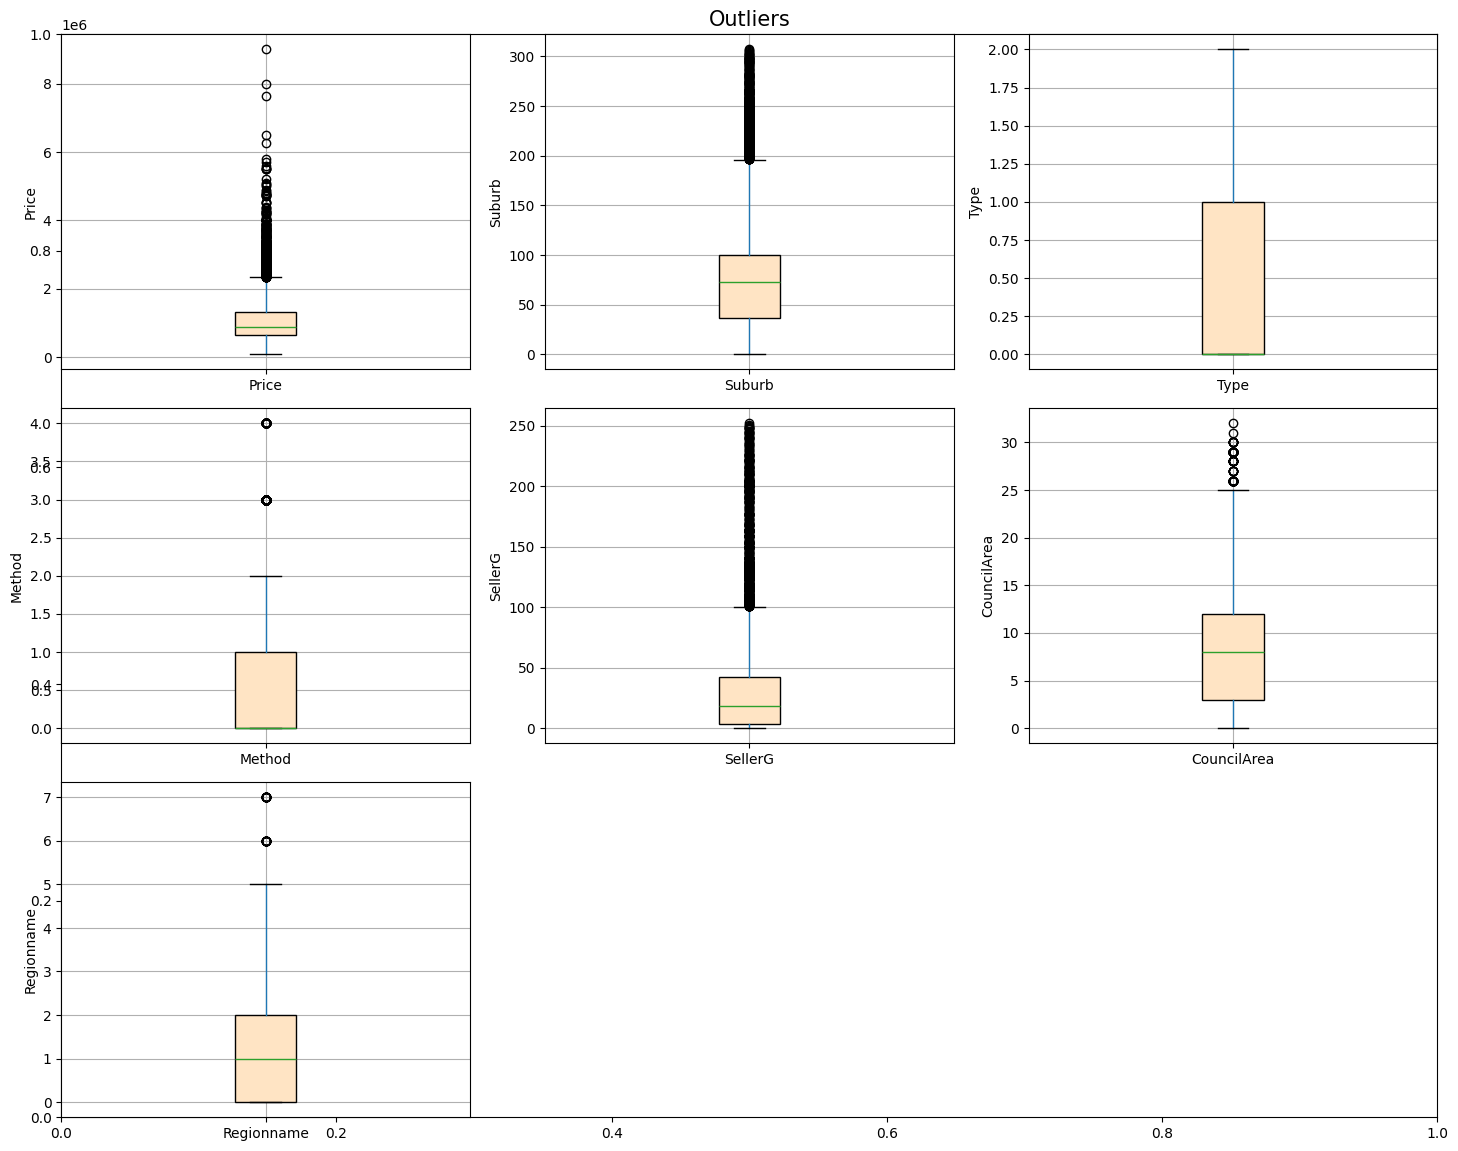

In [178]:
plt.figure(figsize=(15, 12))
plt.title("Outliers", fontsize=15)
features = melbourne_data[
    ["Price", "Suburb", "Type", "Method", "SellerG", "CouncilArea", "Regionname"]
]
for count, feature in enumerate(features.columns, start=1):
    plt.subplot(3, 3, count)
    fig = features.boxplot(
        column=feature,
        figsize=(5, 4),
        patch_artist=True,
        boxprops={"facecolor": "bisque"},
    )
    fig.set_ylabel(feature)
    plt.tight_layout()

#### Data Frequencies

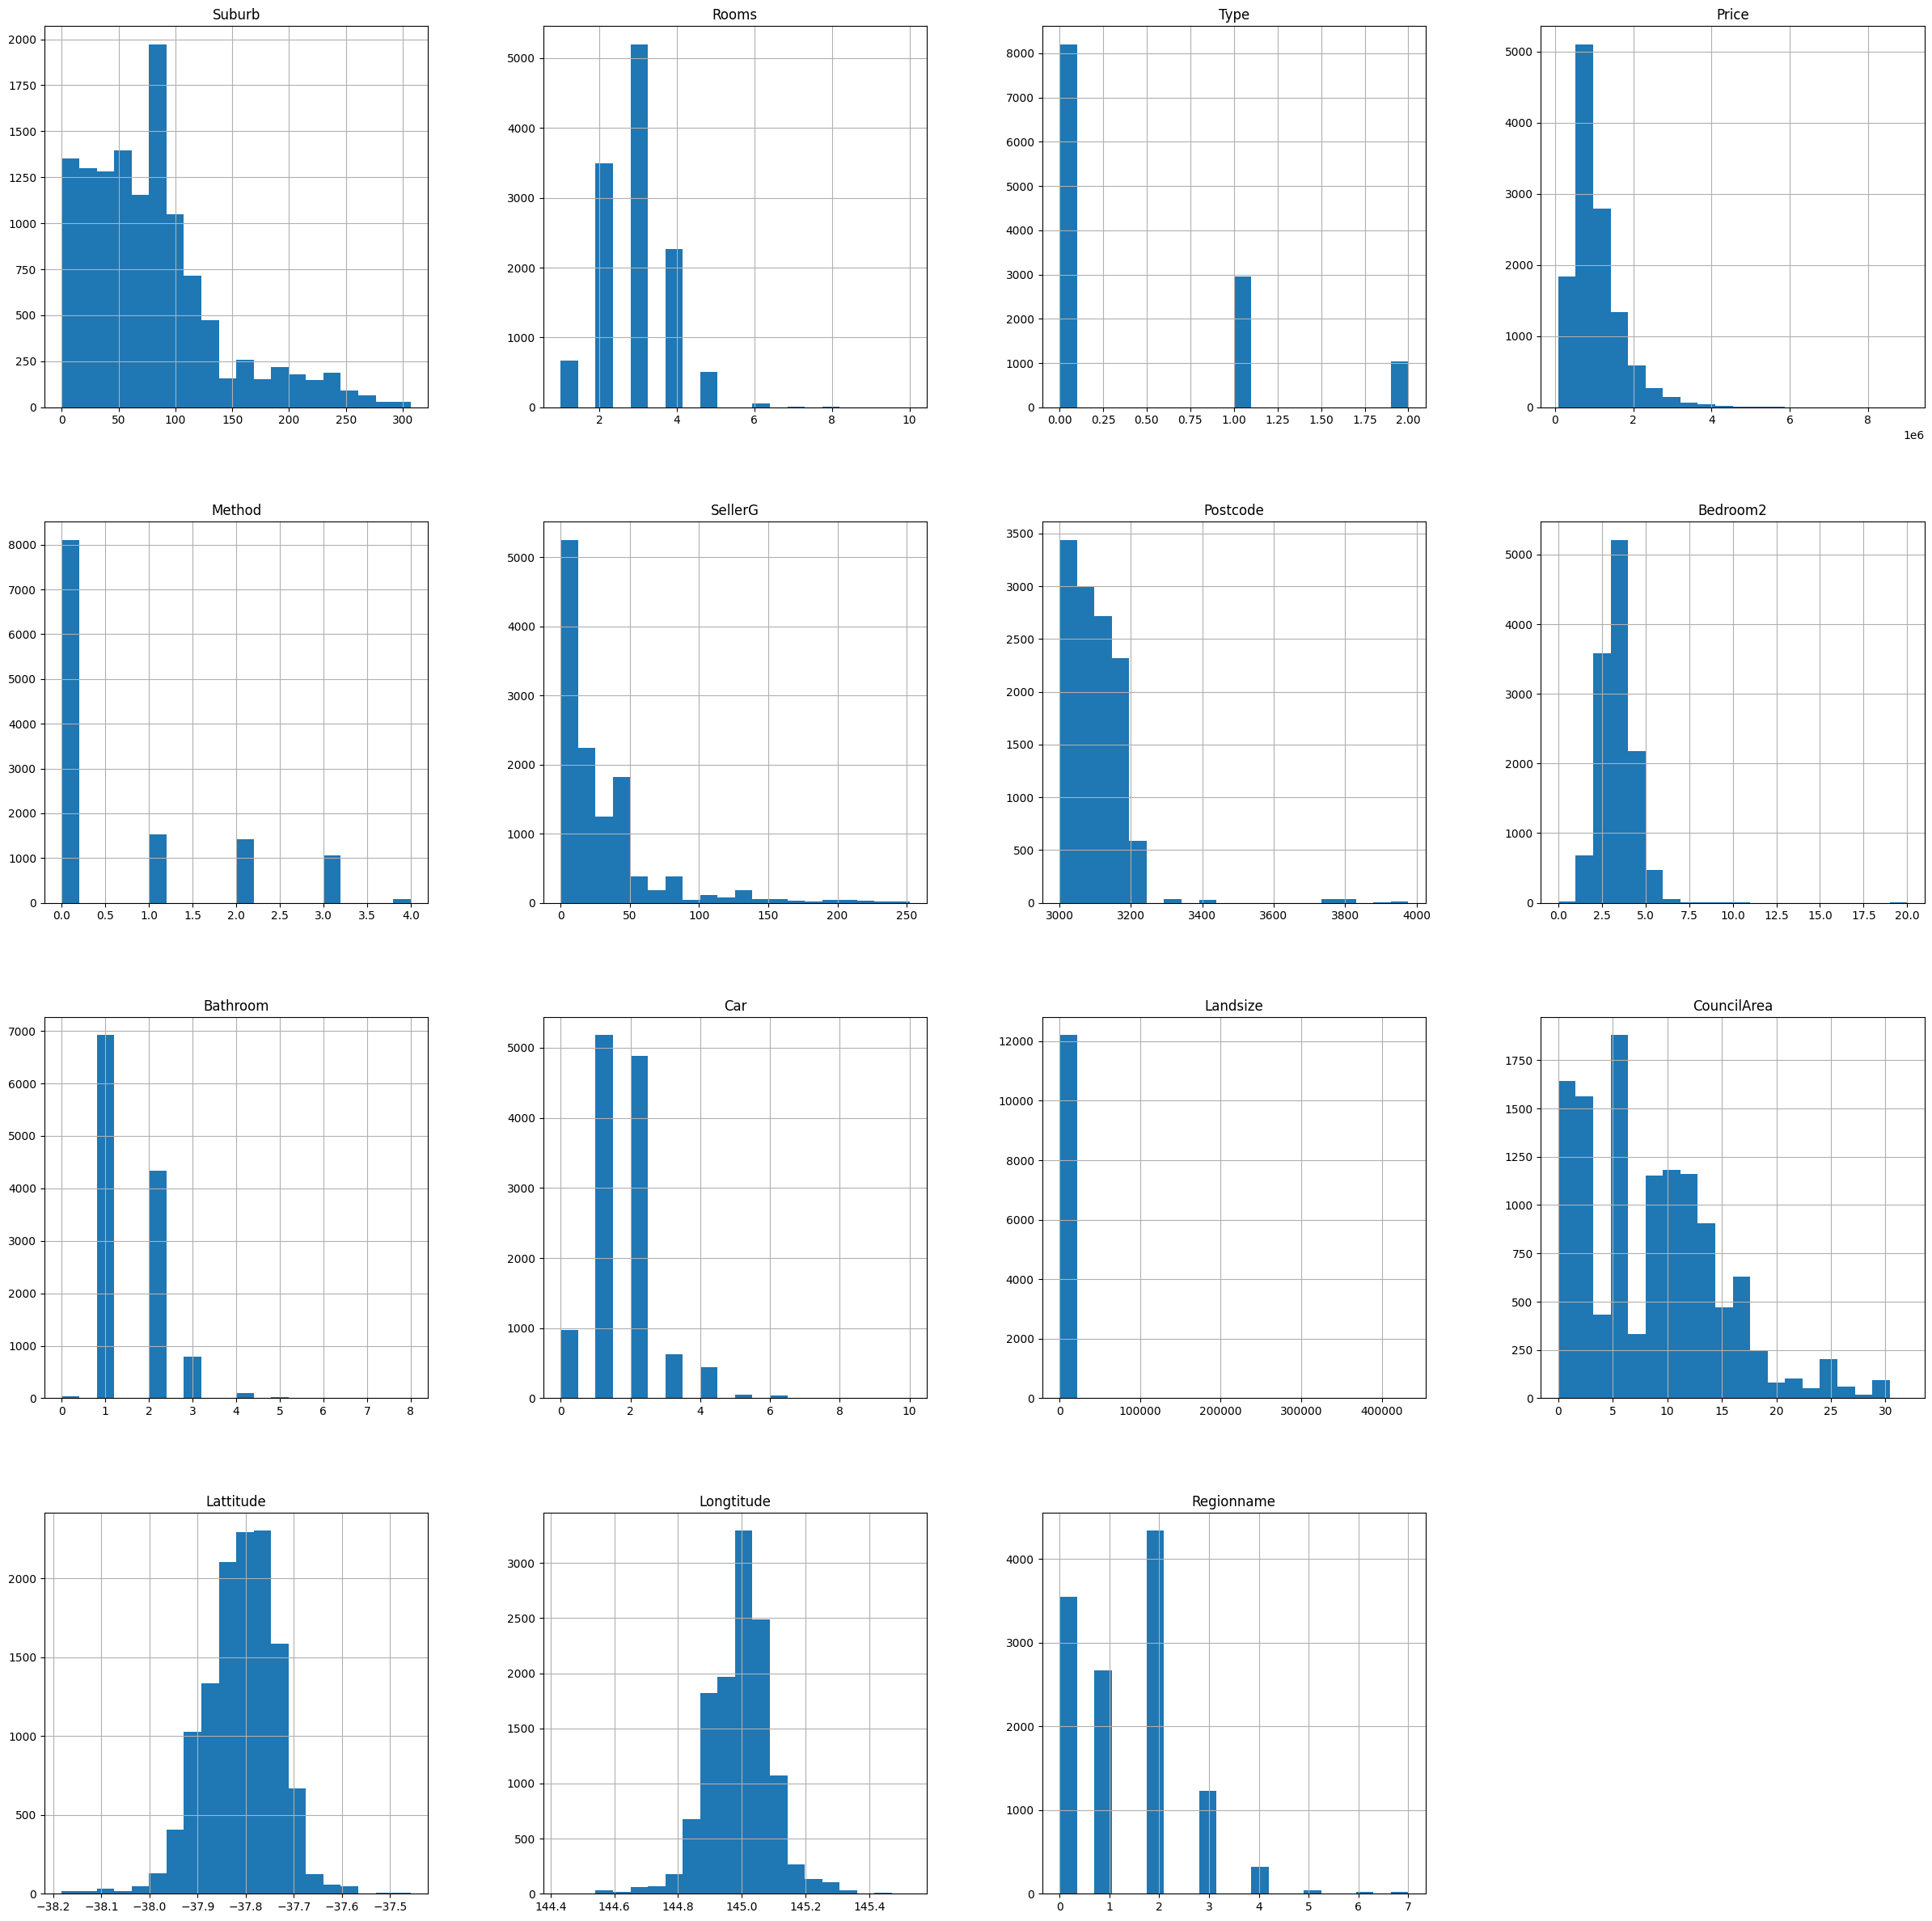

In [179]:
hist = melbourne_data.hist(bins=20, figsize=(30, 30))

#### Price-features correlation

<Axes: >

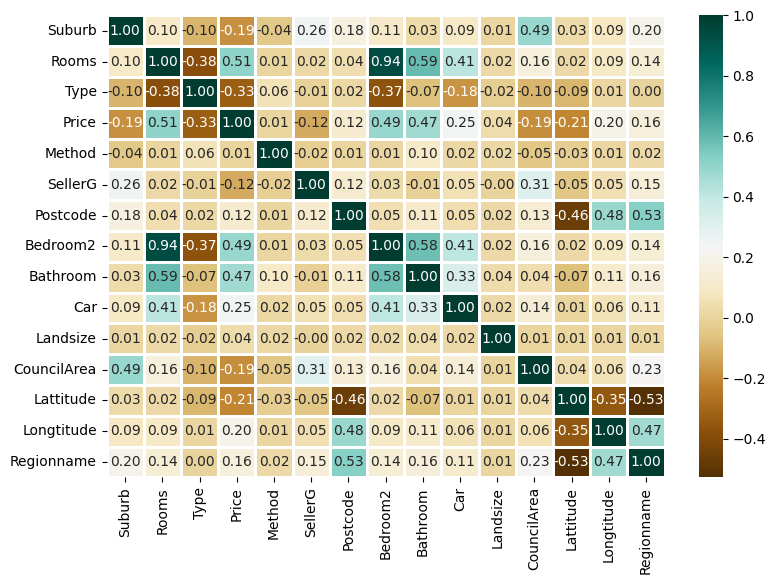

In [180]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(melbourne_data.corr(), cmap="BrBG", fmt=".2f", linewidths=2, annot=True)